In [1]:
from ProjectFunctions import *

# Find the Phase Transition via Staggered Magnetization and other Proxies

In [2]:
#generate an instance and find groundstate
length = 8
hval = 0.1
jij = generate_jij(length, 14, 13)
Hint, Hintdiag = sg_interaction(length, jij)
Hfield = sg_field(length)
H = Hint + (hval * Hfield)
E, psi = H.groundstate()
minenergy, degeneracy, groundpos, states = find_degeneracy(length, Hintdiag)
print(states)

#create the staggered magnetization operator
stagmag = staggered_magnetization(length, states)
print(stagmag)

['00110110', '11001001']
Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2, 2], [2, 2, 2, 2, 2, 2, 2, 2]], shape=(256, 256), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.   -0.25  0.   ...  0.    0.    0.  ]
 [ 0.    0.    0.25 ...  0.    0.    0.  ]
 ...
 [ 0.    0.    0.   ... -0.25  0.    0.  ]
 [ 0.    0.    0.   ...  0.    0.25  0.  ]
 [ 0.    0.    0.   ...  0.    0.    0.  ]]


In [3]:
#calculate the expectation value of the square of the staggered magnetization operator over a range of h values
#the max slope of this curve will give the phase transition
plotlist = []
for hval in np.arange(0.1, 6, 0.1):
    H = Hint + (hval * Hfield)
    E, psi = H.groundstate()
    expectvalue = Q.expect((stagmag**2), psi)
    plotlist.append(expectvalue)

In [4]:
%%time
#Calculate the mutual information distance to find the other proxies for phase transitions
hvals = np.arange(0.1, 6, 0.1)
alldist = {}
allminfo = {}
# Generate all possible pairs of positions
for h in hvals:
    distancelist = []
    minfolist = []
    H = Hint + (h * Hfield)
    E, psi = H.groundstate()
    for i in range(length):
        for j in range(i + 1, length):
            minfo, distance = mutual_info(length, psi, [i], [j])
            distancelist.append(distance)
            minfolist.append(minfo)
    alldist.update({h:distancelist})
    allminfo.update({h:minfolist})
#print(alldist)
ratiodict, maxh, maxratio, stdevdict, meandict = max_variance_ratio(alldist, hvals)

CPU times: total: 1min 4s
Wall time: 16.5 s


In [5]:
#find the transition points from each curve
stagmag_max_slope, peak_covar, mean_max_slope, peak_stdev = find_transitions(np.arange(0.1, 6, 0.1), plotlist, ratiodict, stdevdict, meandict)

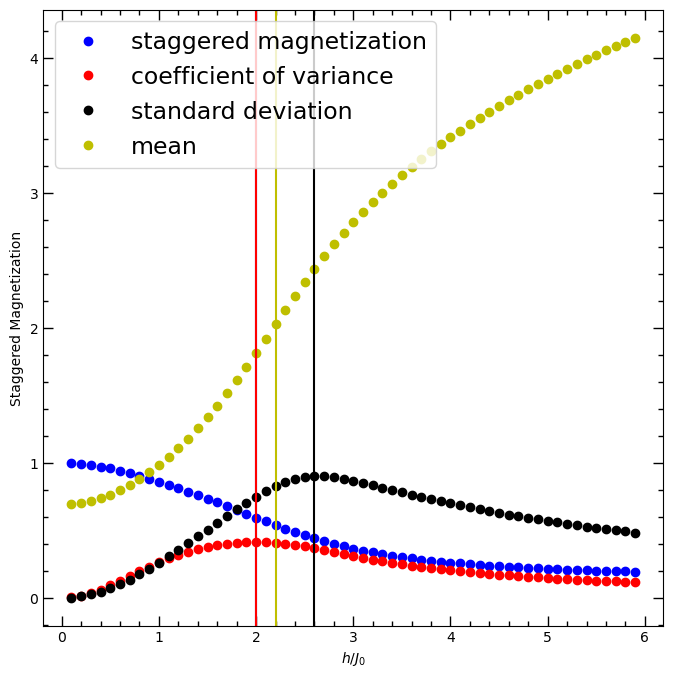

In [6]:
#plot each curve
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel(r"$h/J_0$")
ax.set_ylabel(r"Staggered Magnetization")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

means = []
for val in meandict.values():
    means.append(val)

#plotting the transition curves
p1 = plt.plot(np.arange(0.1, 6, 0.1), plotlist, 'ob', label = 'staggered magnetization')
p2 = plt.plot(np.arange(0.1, 6, 0.1), ratiodict.values(), 'or', label = 'coefficient of variance')
p3 = plt.plot(np.arange(0.1, 6, 0.1), stdevdict.values(), 'ok', label = 'standard deviation')
p4 = plt.plot(np.arange(0.1, 6, 0.1), means, 'oy', label = 'mean')

#plotting a vertial line at each respective phase transition point
transition1 = plt.axvline(x=stagmag_max_slope, color='b')
transtion2 = plt.axvline(x=peak_covar, color='r')
transition3 = plt.axvline(x=peak_stdev, color='k')
transition4 = plt.axvline(x=mean_max_slope, color='y')
plt.legend()

plt.show()

# Look for Trends in Means of Finding Phase Transitions

In [7]:
#read from previously generated classical data file to pull out degeneracy 2 seeds
length = 8
classdat = read_classical_data('N8_classical_data_array.txt')
seeds = [int(row[0]) for row in classdat if row[1] == 2]
Hfield = sg_field(length)
hvals = np.arange(0.5, 3, 0.01)

In [14]:
%%time
#find transitions for each seed over the range of h values
#note this is a very small sample and the result will tell us nothing.
#This is a very slow calculation, so few seeds were done to save time
transitionsdict = generate_transitions_data(length, Hfield, seeds[0:10], hvals)
#save the transition data to a text file to avoid the computation time again
save_dict_to_array_file(transitionsdict, 'transitions_per_seed_fine_fixed.txt')

CPU times: total: 45min 54s
Wall time: 11min 41s


In [15]:
#read from text file with the transition data
transitions2 = read_array_data('transitions_per_seed_fine_fixed.txt')

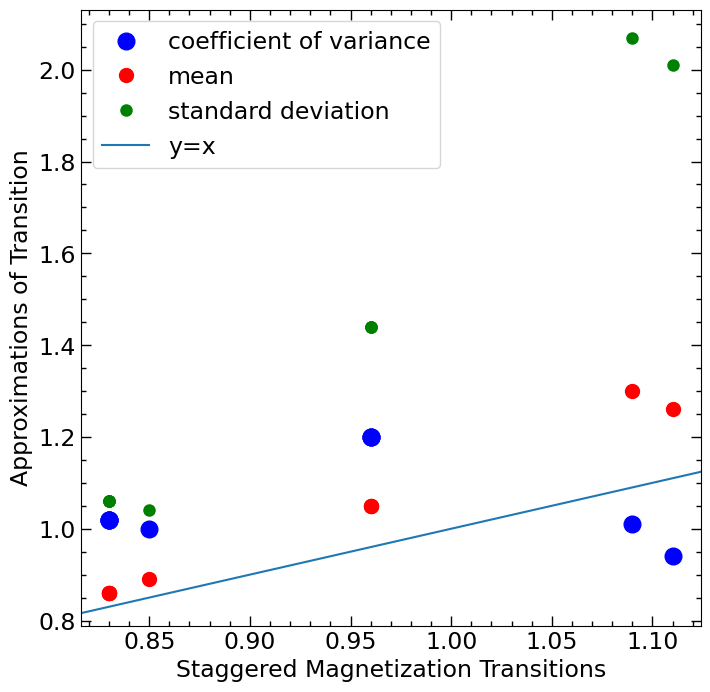

In [16]:
Create the graph
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 17})
# label the axes
ax.set_xlabel("Staggered Magnetization Transitions")
ax.set_ylabel("Approximations of Transition")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')


#plot the transition proxies compared to the staggered magnetization transition for all of the seeds
p1 = plt.plot(transitions2[:,1], transitions2[:,3], 'ob', markersize = 12, label = 'coefficient of variance')
p2 = plt.plot(transitions2[:,1], transitions2[:,2], 'or', markersize = 10, label = 'mean')
p3 = plt.plot(transitions2[:,1], transitions2[:,4], 'og', markersize = 8, label = 'standard deviation')
p4 = plt.axline((0.85,0.85), slope = 1, label = 'y=x')
plt.legend()
#plt.savefig("Comparing Phase Transitions.pdf")
plt.show()

In [17]:
#determine strength of linear relationship
correlation_coefficient, p_value = stats.pearsonr(transitions2[:,1], transitions2[:,3])
print('Coefficient of variance linear correlation coefficient: ' + str(correlation_coefficient) + ' and p val: ' + str(p_value))

correlation_coefficient, p_value = stats.pearsonr(transitions2[:,1], transitions2[:,2])
print('Mean linear correlation coefficient: ' + str(correlation_coefficient) + ' and p val: ' + str(p_value))

correlation_coefficient, p_value = stats.pearsonr(transitions2[:,1], transitions2[:,4])
print('Standard deviation linear correlation coefficient: ' + str(correlation_coefficient) + ' and p val: ' + str(p_value))

Coefficient of variance linear correlation coefficient: 0.04129976532037191 and p val: 0.9098107015277649
Mean linear correlation coefficient: 0.9945024272249028 and p val: 3.9700322628557215e-09
Standard deviation linear correlation coefficient: 0.9896559700485482 and p val: 4.946933390545543e-08
